# Miniproyecto Semana 1 — Informe técnico inicial de viabilidad de IA con datos

**Asignatura:** Profundización III — Inteligencia Artificial aplicada  
**Semana:** 1  
**Valor:** **60 puntos**  
**Formato:** notebook técnico reproducible  
**Entrega:** notebook `.ipynb` ejecutado + dataset usado + enlace o evidencia del repositorio, si aplica.

---

## Propósito

Durante la primera semana se trabajó una idea central:

> **Primero problema, después línea base, luego complejidad justificada.**

Este miniproyecto ya no se plantea como una lista de ejercicios aislados. La tarea consiste en actuar como un/a **analista junior de IA** que recibe un conjunto de datos y debe entregar un diagnóstico técnico inicial. El objetivo no es entrenar el modelo más complejo, sino responder con criterio:

- qué problema de IA puede formularse razonablemente;
- qué tan listos están los datos;
- qué variables sirven y cuáles pueden ser problemáticas;
- cuál sería una línea base honesta;
- qué métrica inicial tendría sentido;
- qué límites, riesgos y próximos pasos deben documentarse.

## Contexto profesional del dataset suministrado

Una planta piloto de manufactura registra información por turno de varios equipos electromecánicos. La coordinación de mantenimiento quiere explorar si, con estos datos, puede construir una solución de IA que apoye decisiones como:

- anticipar estados de **normalidad**, **alerta** o **falla**;
- estimar el consumo energético de un turno;
- detectar registros anómalos de operación;
- identificar perfiles de operación de los equipos.

Los datos son **sintéticos** y fueron generados para fines académicos. Aunque no corresponden a una empresa real ni contienen datos personales, incluyen problemas típicos de datos operativos: faltantes, duplicados, categorías inconsistentes, valores físicamente sospechosos, clases desbalanceadas y variables que podrían generar fuga de información.

### Archivo suministrado

El archivo que acompaña este notebook es:

`datos_celda_industrial_sinteticos.csv`

Para trabajar en Colab, suba el CSV al mismo entorno del notebook. Para trabajar localmente, deje el CSV en la misma carpeta que este notebook.

## Rutas permitidas

Puede desarrollar el miniproyecto por una de estas dos rutas:

| Ruta | Descripción | Condición |
|---|---|---|
| **A. Dataset suministrado** | Usar `datos_celda_industrial_sinteticos.csv` | Ruta recomendada. Permite comparar mejor las entregas. |
| **B. Dataset propio** | Usar un dataset descargado o de interés personal | Debe cumplir los requisitos mínimos indicados abajo. |

### Requisitos para dataset propio

Si usa un dataset propio, debe cumplir como mínimo:

- al menos **80 registros**;
- al menos **5 variables útiles**;
- al menos **3 variables numéricas**;
- fuente clara: enlace, repositorio, institución o explicación de generación;
- descripción del contexto y significado de las variables;
- ausencia de datos personales, sensibles o identificables;
- posibilidad razonable de formular una tarea de clasificación, regresión, agrupamiento o anomalías;
- archivo adjunto o instrucciones suficientes para reproducir la carga del dataset.

Si el dataset propio no cumple estos requisitos, la entrega podrá ser evaluada como incompleta.

## Diccionario inicial del dataset suministrado

| Variable | Descripción | Observación inicial |
|---|---|---|
| `registro_id` | Identificador del registro | Puede ayudar a detectar duplicados, pero no debería usarse como variable predictora. |
| `fecha_turno` | Fecha del registro | Puede requerir conversión a fecha. |
| `equipo_id` | Equipo monitoreado | Variable categórica. |
| `linea_produccion` | Línea donde opera el equipo | Variable categórica. |
| `turno` | Mañana, tarde o noche | Puede tener inconsistencias de escritura. |
| `horas_operacion_acumuladas` | Horas totales acumuladas del equipo | Variable numérica. |
| `horas_desde_mantenimiento` | Horas desde el último mantenimiento | Variable numérica. |
| `temperatura_C` | Temperatura del equipo en °C | Revisar rangos físicamente sospechosos. |
| `vibracion_mm_s` | Vibración RMS en mm/s | Revisar valores negativos o extremos. |
| `corriente_A` | Corriente eléctrica en amperios | Variable numérica. |
| `velocidad_rpm` | Velocidad de operación | Revisar valores negativos o imposibles. |
| `humedad_pct` | Humedad relativa ambiente | Usualmente debería estar entre 0 y 100 %. |
| `carga_pct` | Carga de operación del equipo | Revisar si valores superiores a 100 % son admisibles o no. |
| `consumo_kWh` | Consumo energético por turno | Puede ser variable objetivo para regresión. |
| `mantenimiento_reciente` | Indica si el equipo tuvo mantenimiento reciente | Puede tener inconsistencias de escritura. |
| `diagnostico_post_turno` | Diagnóstico realizado después del turno | Posible fuga de información si se usa para predecir durante el turno. |
| `parada_reportada_post_turno` | Indica si se reportó parada después del turno | Posible fuga de información si se usa como entrada predictiva. |
| `estado_operativo` | Estado final: normal, alerta o falla | Puede ser variable objetivo para clasificación. |

# 0. Identificación del equipo o estudiante

Complete la siguiente ficha.

| Campo | Respuesta |
|---|---|
| Nombre(s) | Daniel David Saenz Lozano |
| Dataset usado | Suministrado |
| Nombre del archivo de datos | `datos_celda_industrial_sinteticos.csv` |
| Enlace al repositorio o carpeta de entrega, si aplica | Carpeta organizada `S1_Miniproyecto_Semana1_materiales/` con `data/`, `notebooks/`, `docs/` y `README.txt`. |
| Fecha de entrega | 2026-06-15 |

# 1. Carga del dataset

Ejecute la siguiente celda para cargar el dataset suministrado. Si usa un dataset propio, cambie el valor de `DATA_PATH` y documente la fuente en la sección 2.

In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path(r"C:\Users\USER\OneDrive\Escritorio\S1_Miniproyecto_Semana1_materiales\data\datos_celda_industrial_sinteticos.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el archivo CSV. Suba 'datos_celda_industrial_sinteticos.csv' "
        "al mismo entorno del notebook o cambie DATA_PATH por la ruta correcta."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,registro_id,fecha_turno,equipo_id,linea_produccion,turno,horas_operacion_acumuladas,horas_desde_mantenimiento,temperatura_C,vibracion_mm_s,corriente_A,velocidad_rpm,humedad_pct,carga_pct,consumo_kWh,mantenimiento_reciente,diagnostico_post_turno,parada_reportada_post_turno,estado_operativo
0,R-0178,2026-01-31,EQ-10,Línea B,mañana,2743.0,95.8,47.05,3.44,5.62,1219.6,59.6,61.8,11.53,no,normal,no,normal
1,R-0216,2026-01-10,EQ-01,Línea A,noche,4256.0,59.9,60.59,3.11,7.79,1557.4,55.3,71.1,14.62,no,normal,no,normal
2,R-0072,2026-01-22,EQ-09,Línea A,mañana,621.0,132.4,62.85,4.57,10.55,1632.5,36.8,100.9,17.68,no,normal,no,normal
3,R-0021,2026-02-02,EQ-06,Línea C,tarde,1990.0,103.2,50.02,4.19,5.58,959.2,51.0,58.5,10.58,no,normal,No,normal
4,R-0080,2026-01-06,EQ-05,Línea A,noche,4227.0,92.9,51.29,2.89,6.77,1606.9,57.6,63.4,12.57,no,normal,no,normal


Ejecute una inspección inicial. Puede agregar celdas de código adicionales si lo considera necesario.

In [2]:
# Inspección mínima sugerida. Puede modificar o complementar estas líneas.
print("Filas y columnas:", df.shape)
df.info()

Filas y columnas: (225, 18)
<class 'pandas.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   registro_id                  225 non-null    str    
 1   fecha_turno                  225 non-null    str    
 2   equipo_id                    225 non-null    str    
 3   linea_produccion             225 non-null    str    
 4   turno                        222 non-null    str    
 5   horas_operacion_acumuladas   225 non-null    float64
 6   horas_desde_mantenimiento    225 non-null    float64
 7   temperatura_C                220 non-null    float64
 8   vibracion_mm_s               219 non-null    float64
 9   corriente_A                  221 non-null    float64
 10  velocidad_rpm                225 non-null    float64
 11  humedad_pct                  220 non-null    float64
 12  carga_pct                    225 non-null    float64
 13  con

In [3]:
# Resumen estadístico inicial de variables numéricas.
df.describe()

,horas_operacion_acumuladas,horas_desde_mantenimiento,temperatura_C,vibracion_mm_s,corriente_A,velocidad_rpm,humedad_pct,carga_pct,consumo_kWh
count,225.000000,225.000000,220.000000,219.000000,221.000000,225.000000,220.000000,225.000000,225.000000
mean,2735.688889,141.585333,51.281864,4.678311,6.896697,1298.159556,55.744091,67.738667,11.985778
std,1444.563049,74.121447,77.985866,3.251169,1.489051,246.877467,14.505515,18.968281,2.532720
min,379.000000,12.700000,-999.000000,-1.400000,2.770000,-250.000000,22.000000,20.000000,-5.500000
25%,1470.000000,90.900000,49.662500,3.290000,5.810000,1133.600000,45.750000,56.200000,10.420000
50%,2712.000000,128.800000,53.695000,4.190000,6.840000,1353.800000,56.400000,66.200000,11.980000
75%,4012.000000,174.700000,58.125000,5.565000,8.080000,1474.500000,64.350000,80.000000,13.520000
max,5167.000000,379.600000,520.000000,45.000000,10.550000,1754.700000,130.000000,142.000000,18.070000


# 2. Ficha técnica inicial del dataset (**10 puntos**)

Construya una ficha breve del dataset. No copie únicamente los nombres de las columnas: explique qué representan en el contexto del problema.

## Respuesta del estudiante — Ficha del dataset

| Elemento | Respuesta |
|---|---|
| Nombre del dataset | `datos_celda_industrial_sinteticos.csv` |
| Fuente u origen | Datos suministrados por el profesor |
| Contexto del problema | El dataset representa registros por turno de una celda industrial con equipos electromecánicos, cada fila describe condiciones de operación medidas o registradas que sirven para evaluar si los datos permiten apoyar decisiones de operación o mantenimiento mediante una primera línea base de IA. |
| Número de registros | 255 |
| Número de variables | 18 |
| Variables numéricas principales |  `horas_operacion_acumuladas`, `horas_desde_mantenimiento`, `temperatura_C`, `vibracion_mm_s`, `corriente_A`, `velocidad_rpm`, `humedad_pct`, `carga_pct`, `consumo_kWh`|
| Variables categóricas principales |  `equipo_id`, `linea_produccion`, `turno`, `mantenimiento_reciente`, `diagnostico_post_turno`, `parada_reportada_post_turno`, `estado_operativo` |
| Posible variable objetivo para clasificación | `estado_operativo` con clases `normal`, `alerta` y `falla` |
| Posible variable objetivo para regresión | `consumo_kWh` si la idea es estimar elconsumo energético |
| Variables que podrían NO usarse como entrada |  `registro_id` es un identificador, `diagnostico_post_turno` y `parada_reportada_post_turno` pasan después del turno por lo que filtran información de la respuesta, `fecha_turno` requeriría transformación antes de usarla |
| Riesgos iniciales de privacidad, trazabilidad o mal uso | el dataset utilizado es el dado por el profesor y no contiene datos personales, son datos unicamente hechos con fines educativos |

nota: toda la información fue sacada del dataset y la información suministrada en este cuaderno

### Preguntas guía

1. ¿Qué situación real intenta representar el dataset?
   
con la información de (Contexto profesional del dataset suministrado) el dataset representa registros por turno de una celda industrial con equipos electromecánicos, cada fila describe condiciones de operación medidas o registradas que sirven para evaluar si los datos permiten apoyar decisiones de operación o mantenimiento mediante una primera línea base de IA.

2. ¿Quién podría usar el resultado de un análisis de IA basado en estos datos?

una persona autorizada y caácitada para la tarea, esos pueden ser: un coordinador de planta, un ingeniero de procesos, un analista de datos industriales, etc.

3. ¿Qué decisión se intentaría apoyar?

primero saber si una celda o equipo está operando bien o tiene alguna falla, priorizar revisiones de mantenimiento, detectar anómalias y mirar cuándo revisar un equipo antes de que ocurra una parada.

4. ¿El problema parece requerir IA o podría empezar con reglas simples? Justifique.

puede empezar con reglas simples como reglas tomadas de sensores de vibración, temperatura, carga o consumo, estas podrían servir como primera línea base, luego la IA se justificaría si esas reglas simples no son suficientes, si hay muchas variables interactuando o si se quiere mejorar la detección de estados de alerta o falla con datos anteriores

# 3. Exploración inicial y diagnóstico de calidad de datos (**15 puntos**)

Realice un análisis exploratorio básico. Como mínimo, revise:

- primeras filas;
- tipos de datos;
- valores faltantes;
- duplicados;
- distribución de variables categóricas importantes;
- resumen estadístico de variables numéricas;
- valores fuera de rango o físicamente sospechosos;
- distribución de la variable objetivo, si decide usar una.

Puede usar `head()`, `info()`, `describe()`, `isna()`, `duplicated()`, `value_counts()`, tablas y visualizaciones simples. No se espera una limpieza perfecta todavía; se espera un diagnóstico claro.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [5]:
# Primeras filas
print("Primeras filas:")
display(df.head())

# Tipos y no nulos
print("\nInformación general:")
df.info()

Primeras filas:


,registro_id,fecha_turno,equipo_id,linea_produccion,turno,horas_operacion_acumuladas,horas_desde_mantenimiento,temperatura_C,vibracion_mm_s,corriente_A,velocidad_rpm,humedad_pct,carga_pct,consumo_kWh,mantenimiento_reciente,diagnostico_post_turno,parada_reportada_post_turno,estado_operativo
0,R-0178,2026-01-31,EQ-10,Línea B,mañana,2743.0,95.8,47.05,3.44,5.62,1219.6,59.6,61.8,11.53,no,normal,no,normal
1,R-0216,2026-01-10,EQ-01,Línea A,noche,4256.0,59.9,60.59,3.11,7.79,1557.4,55.3,71.1,14.62,no,normal,no,normal
2,R-0072,2026-01-22,EQ-09,Línea A,mañana,621.0,132.4,62.85,4.57,10.55,1632.5,36.8,100.9,17.68,no,normal,no,normal
3,R-0021,2026-02-02,EQ-06,Línea C,tarde,1990.0,103.2,50.02,4.19,5.58,959.2,51.0,58.5,10.58,no,normal,No,normal
4,R-0080,2026-01-06,EQ-05,Línea A,noche,4227.0,92.9,51.29,2.89,6.77,1606.9,57.6,63.4,12.57,no,normal,no,normal



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   registro_id                  225 non-null    str    
 1   fecha_turno                  225 non-null    str    
 2   equipo_id                    225 non-null    str    
 3   linea_produccion             225 non-null    str    
 4   turno                        222 non-null    str    
 5   horas_operacion_acumuladas   225 non-null    float64
 6   horas_desde_mantenimiento    225 non-null    float64
 7   temperatura_C                220 non-null    float64
 8   vibracion_mm_s               219 non-null    float64
 9   corriente_A                  221 non-null    float64
 10  velocidad_rpm                225 non-null    float64
 11  humedad_pct                  220 non-null    float64
 12  carga_pct                    225 non-null    float64
 13  consumo_k

In [6]:
# Resumen numérico
numeric_cols = df.select_dtypes(include="number").columns
numeric_summary = df[numeric_cols].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
horas_operacion_acumuladas,225.0,2735.689,1444.563,379.00,1470.000,2712.000,4012.000,5167.00
horas_desde_mantenimiento,225.0,141.585,74.121,12.70,90.900,128.800,174.700,379.60
temperatura_C,220.0,51.282,77.986,-999.00,49.663,53.695,58.125,520.00
vibracion_mm_s,219.0,4.678,3.251,-1.40,3.290,4.190,5.565,45.00
corriente_A,221.0,6.897,1.489,2.77,5.810,6.840,8.080,10.55
velocidad_rpm,225.0,1298.160,246.877,-250.00,1133.600,1353.800,1474.500,1754.70
humedad_pct,220.0,55.744,14.506,22.00,45.750,56.400,64.350,130.00
carga_pct,225.0,67.739,18.968,20.00,56.200,66.200,80.000,142.00
consumo_kWh,225.0,11.986,2.533,-5.50,10.420,11.980,13.520,18.07


In [7]:
# Faltantes por columna
missing_summary = (
    df.isna()
    .sum()
    .to_frame("faltantes")
    .assign(porcentaje=lambda x: 100 * x["faltantes"] / len(df))
    .sort_values("faltantes", ascending=False)
)

missing_summary

,faltantes,porcentaje
vibracion_mm_s,6,2.667
temperatura_C,5,2.222
humedad_pct,5,2.222
corriente_A,4,1.778
diagnostico_post_turno,3,1.333
turno,3,1.333
fecha_turno,0,0.000
registro_id,0,0.000
horas_operacion_acumuladas,0,0.000
linea_produccion,0,0.000


In [8]:
# Duplicados exactos
print("Duplicados exactos:", df.duplicated().sum())

# Frecuencia de estado operativo
estado_counts = df["estado_operativo"].value_counts(dropna=False)
estado_counts

Duplicados exactos: 5


estado_operativo
normal    157
alerta     49
falla      19
Name: count, dtype: int64

In [9]:
def diagnostico_columnas(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Devuelve un resumen básico por columna para inspección inicial."""
    rows = []
    for col in dataframe.columns:
        serie = dataframe[col]
        row = {
            "columna": col,
            "tipo": str(serie.dtype),
            "faltantes": int(serie.isna().sum()),
            "% faltantes": round(100 * serie.isna().mean(), 2),
            "únicos": int(serie.nunique(dropna=True)),
            "ejemplo": serie.dropna().iloc[0] if serie.dropna().shape[0] else np.nan,
        }
        if pd.api.types.is_numeric_dtype(serie):
            row["mínimo"] = serie.min()
            row["máximo"] = serie.max()
        else:
            row["mínimo"] = np.nan
            row["máximo"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

resumen_columnas = diagnostico_columnas(df)
resumen_columnas

,columna,tipo,faltantes,% faltantes,únicos,ejemplo,mínimo,máximo
0,registro_id,str,0,0.00,220,R-0178,NaN,NaN
1,fecha_turno,str,0,0.00,40,2026-01-31,NaN,NaN
2,equipo_id,str,0,0.00,12,EQ-10,NaN,NaN
3,linea_produccion,str,0,0.00,3,Línea B,NaN,NaN
4,turno,str,3,1.33,9,mañana,NaN,NaN
5,horas_operacion_acumuladas,float64,0,0.00,213,2743.0,379.00,5167.00
6,horas_desde_mantenimiento,float64,0,0.00,208,95.8,12.70,379.60
7,temperatura_C,float64,5,2.22,210,47.05,-999.00,520.00
8,vibracion_mm_s,float64,6,2.67,187,3.44,-1.40,45.00
9,corriente_A,float64,4,1.78,177,5.62,2.77,10.55


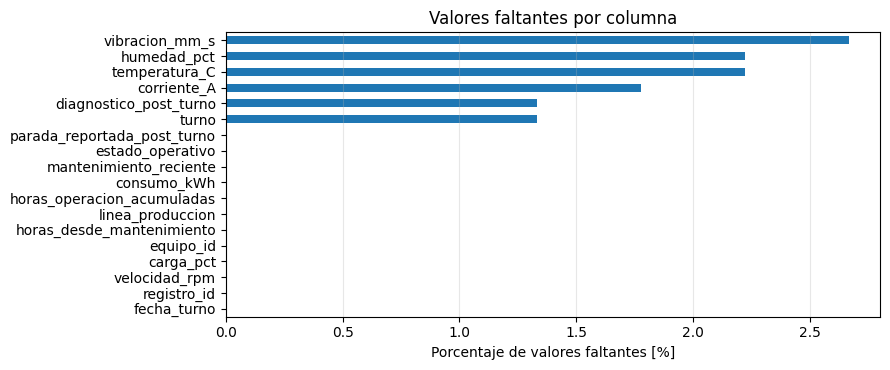

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.8))
missing_summary["porcentaje"].sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Porcentaje de valores faltantes [%]")
ax.set_title("Valores faltantes por columna")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

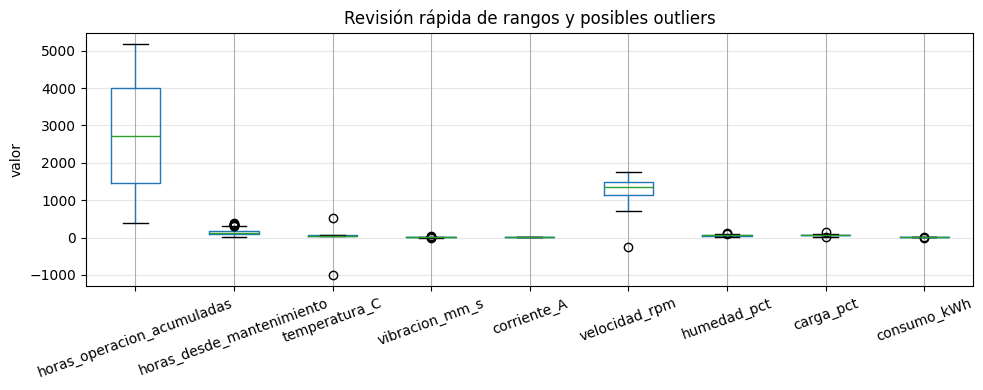

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
df[numeric_cols].boxplot(ax=ax)
ax.set_title("Revisión rápida de rangos y posibles outliers")
ax.set_ylabel("valor")
plt.xticks(rotation=20)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Respuesta del estudiante — Diagnóstico de calidad

Complete con hallazgos concretos, citando columnas y ejemplos cuando sea posible.

| Aspecto revisado | Hallazgos | Acción recomendada antes de modelar |
|---|---|---|
| Valores faltantes | `vibracion_mm_s` tiene 6 faltantes, `temperatura_C` 5, `humedad_pct` 5, `corriente_A` 4, `diagnostico_post_turno` 3 y `turno` 3. | Revisar el origen para definir si se imputan, se eliminan o se colocan como limitación |
| Duplicados | 5 duplicados exactos, `registro_id` tiene 225 registros y solo 220 valores únicos | Revisar si los duplicados son registros repetidos por error, si son duplicados exactos, podrían eliminarse |
| Tipos de datos | El dataset tiene 18 columnas: 9 numéricas tipo `float64` y 9 de texto tipo `str`. Las variables numéricas corresponden a mediciones operativas como temperatura, vibración, corriente, velocidad, humedad, carga y consumo. | Mantener las variables numéricas como mediciones. Revisar las columnas de texto como variables categóricas. Si se usa `fecha_turno`, convertirla a formato fecha. |
| Categorías inconsistentes | Algunas variables categóricas tienen más valores únicos de los esperados. Por ejemplo, `turno` tiene 9 valores únicos, aunque conceptualmente debería tener pocas categorías como mañana, tarde y noche. `mantenimiento_reciente` tiene 6 valores únicos y `parada_reportada_post_turno` tiene 4. | Revisar las frecuencias con `value_counts()` y unificar escrituras antes de modelar, por ejemplo mayúsculas/minúsculas y variantes como `sí`, `si`, `No`, `NO`. |
| Valores fuera de rango | A partir del resumen estadístico se observan mínimos y máximos físicamente sospechosos: `temperatura_C` va de -999 a 520, `vibracion_mm_s` tiene mínimo -1.4, `velocidad_rpm` tiene mínimo -250, `humedad_pct` llega a 130, `carga_pct` llega a 142 y `consumo_kWh` tiene mínimo -5.5. | Revisar esos valores con criterio técnico antes de modelar. No corregirlos automáticamente; primero decidir si son errores de captura, unidades mal registradas o eventos atípicos. |
| Posibles outliers | El resumen numérico muestra valores extremos. Por ejemplo, `vibracion_mm_s` tiene máximo 45 mientras que el percentil 75 es 5.565. También hay extremos en temperatura, carga y consumo. | Revisar con boxplots o filtros simples. Documentar si se eliminan, corrigen o conservan como casos raros reales. |
| Posible fuga de información | `diagnostico_post_turno` y `parada_reportada_post_turno` parecen variables registradas después del turno. Si se usan para predecir `estado_operativo`, podrían revelar información cercana a la respuesta. | Excluir esas columnas como entradas si el objetivo es predecir el estado operativo antes o durante el turno. |
| Desbalance de clases, si aplica | La variable `estado_operativo` está desbalanceada: `normal` tiene 157 registros, `alerta` 49 y `falla` 19. | No usar solo accuracy. Si se entrena un modelo, revisar matriz de confusión y métricas por clase, especialmente para la clase `falla`. |

**Decisión:** ¿los datos están listos para construir una línea base? Marque una opción y justifique.

- [ ] Sí.
- [x] Parcialmente.
- [ ] No.

**Justificación:**
Los datos permiten construir una primera línea base porque tienen una variable objetivo clara (`estado_operativo`) y variables operativas útiles pero el diagnóstico muestra faltantes, duplicados, inconsistentencias, valores mínimos y máximos sospechosos, entre otras cosas, por lo que conviene hacer una limpieza antes de modelar.





1:50 p.m.

# 4. Visualizaciones e interpretación (**10 puntos**)

Construya al menos **tres visualizaciones** útiles para entender el dataset. No basta con generar gráficos: debe interpretarlos.

Ejemplos posibles:

- histograma de temperatura, vibración, corriente o consumo;
- barras de `estado_operativo`, `turno`, `linea_produccion` o `mantenimiento_reciente`;
- dispersión entre dos variables numéricas coloreada por estado;
- boxplot para comparar una variable numérica frente a una categoría;
- matriz de dispersión o pairplot si lo considera útil.

Evite gráficos decorativos que no aporten a una decisión técnica.

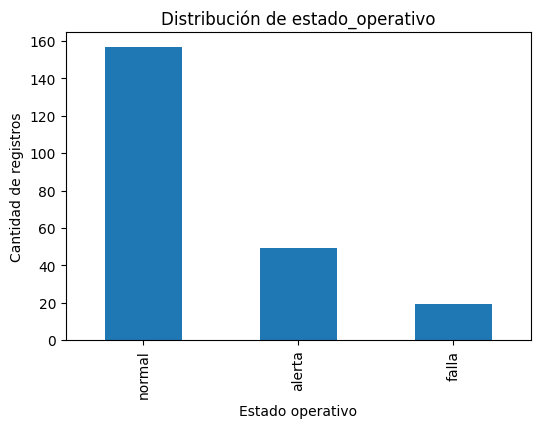

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
df["estado_operativo"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Distribución de estado_operativo")
ax.set_xlabel("Estado operativo")
ax.set_ylabel("Cantidad de registros")
plt.show()

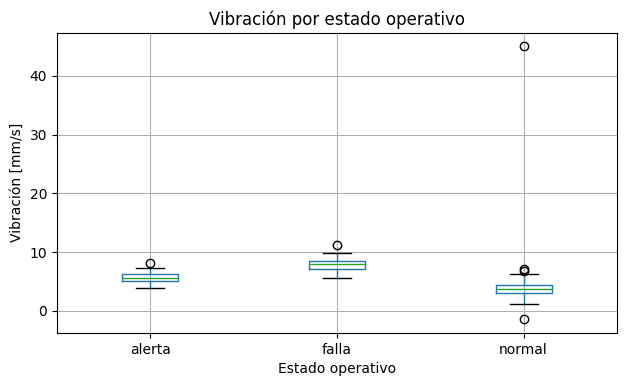

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="vibracion_mm_s", by="estado_operativo", ax=ax)
ax.set_title("Vibración por estado operativo")
ax.set_xlabel("Estado operativo")
ax.set_ylabel("Vibración [mm/s]")
plt.suptitle("")
plt.show()

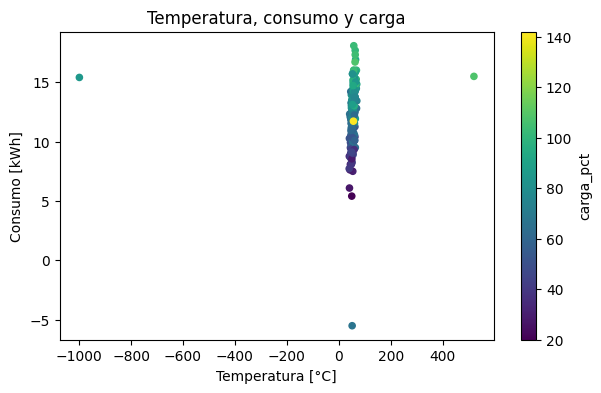

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
df.plot.scatter(
    x="temperatura_C",
    y="consumo_kWh",
    c="carga_pct",
    colormap="viridis",
    ax=ax
)
ax.set_title("Temperatura, consumo y carga")
ax.set_xlabel("Temperatura [°C]")
ax.set_ylabel("Consumo [kWh]")
plt.show()

## Respuesta del estudiante — Interpretación visual

| Visualización | ¿Qué muestra? | ¿Qué decisión o hipótesis permite formular? |
|---|---|---|
| Distribución de `estado_operativo` | Muestra cuántos registros hay en cada clase: `normal`, `alerta` y `falla`. | Permite detectar desbalance de clases. |
| Boxplot de `vibracion_mm_s` por `estado_operativo` | Compara la vibración entre estados operativos y permite ver valores extremos. | Permite formular la hipótesis de que la vibración puede ayudar a identificar estados de alerta o falla. |
| Dispersión entre `temperatura_C`, `consumo_kWh` y `carga_pct` | Muestra la relación entre temperatura, consumo y carga, además de puntos raros. | Permite revisar si hay relación entre variables operativas y detectar valores sospechosos antes de modelar. |

**Conclusión visual general:** El dataset tiene señales útiles para una primera línea base aunque se ve desbalance de clases y valores que deben revisarse antes de entrenar un modelo.


# 5. Formulación de una tarea de IA (**10 puntos**)

Seleccione **una tarea principal** para este miniproyecto. No intente resolver todas a la vez.

| Tipo de tarea | Ejemplo con este dataset |
|---|---|
| Clasificación | Predecir `estado_operativo`: normal, alerta o falla. |
| Regresión | Estimar `consumo_kWh`. |
| Detección de anomalías | Detectar registros operativos raros o riesgosos. |
| Agrupamiento | Encontrar perfiles de operación sin asumir etiquetas reales. |

## Respuesta del estudiante — Tarea seleccionada

| Elemento | Respuesta |
|---|---|
| Tipo de tarea seleccionada | Clasificación supervisada multiclase. |
| Variable objetivo, si aplica | `estado_operativo`, con las clases `normal`, `alerta` y `falla`. |
| Variables de entrada candidatas | `equipo_id`, `linea_produccion`, `turno`, `horas_operacion_acumuladas`, `horas_desde_mantenimiento`, `temperatura_C`, `vibracion_mm_s`, `corriente_A`, `velocidad_rpm`, `humedad_pct`, `carga_pct`, `consumo_kWh` y `mantenimiento_reciente` |
| Variables que excluiría y por qué | Excluiría `registro_id` porque es un identificador. También excluiría `diagnostico_post_turno` y `parada_reportada_post_turno` porque parecen registrarse después del turno y podrían filtrar información de la respuesta. `fecha_turno` no la usaría directamente sin transformarla. |
| Usuario o área que usaría el resultado | Coordinación de mantenimiento, jefe de planta, equipo de operación o ingeniería de procesos. |
| Decisión que apoyaría | Priorizar revisiones de mantenimiento, identificar equipos en alerta o falla y decidir cuándo intervenir una celda industrial. |
| Riesgo principal de equivocarse | Clasificar una falla como normal causar paradas, daños, riesgos operativos y falsas alarmas. |

### Justificación

La tarea de clasificación es razonable porque el dataset contiene una variable objetivo clara que resume el estado de la celda industrial en categorías (`normal`, `alerta` y `falla`), y existen variables operativas que podrían ayudar a predecirla.

La principal limitación es que el dataset tiene problemas de calidad: faltantes, duplicados, categorías inconsistentes, valores sospechosos y desbalance de clases

# 6. Línea base y métrica inicial (**10 puntos**)

Proponga una línea base simple y una métrica inicial coherente con la tarea seleccionada.

La línea base debe ser deliberadamente sencilla. Su función es servir como punto de comparación mínimo, no como solución final.

| Tarea | Línea base posible | Métricas iniciales posibles |
|---|---|---|
| Clasificación | Predecir siempre la clase mayoritaria o usar una regla simple | Accuracy, balanced accuracy, matriz de confusión, precision, recall, F1 |
| Regresión | Predecir siempre el promedio o la mediana | MAE, RMSE, R² |
| Anomalías | Umbral manual sobre vibración, temperatura o corriente | Revisión manual, falsos positivos, falsos negativos |
| Agrupamiento | Agrupar por rangos o perfiles simples | Interpretabilidad de grupos, coherencia técnica; no asumir que clusters son clases reales |

## Respuesta del estudiante — Línea base

| Elemento | Respuesta |
|---|---|
| Línea base propuesta | Usar un `DummyClassifier` que prediga la clase mayoritaria (`normal`) . |
| Por qué esa línea base tiene sentido | Sirve como comparación mínima ya que si un modelo no supera claramente predecir siempre `normal`, no aporta valor. |
| Métrica inicial | Accuracy como primera referencia acompañada de matriz de confusión, balanced accuracy y recall por clase. |
| Por qué no basta con accuracy | Porque la clase `normal` domina el dataset, podria fallar en detectar `falla`. |
| Primer modelo simple posterior a la línea base | arbol de decisión pequeño ya que permite explicar reglas y comparar si variables ayudan a clasificar el estado operativo. |

### Comentario crítico

Una métrica alta como accuracy podría ser engañosa. Si el dataset está desbalanceado y la mayoría de registros pertenecen a la clase normal, un modelo puede acertar muchas veces simplemente prediciendo siempre esa clase pero ese modelo tendría poco valor práctico si no detecta correctamente los casos de falla que son los más importantes en este contexto. Por eso es necesario revisar la matriz de confusión, el recall de la clase falla y métricas como balanced accuracy.

# 7. Conclusión técnica y próximos pasos (**10 puntos**)

Redacte una conclusión como si fuera dirigida a un jefe de mantenimiento, coordinador de planta o líder técnico que debe decidir si vale la pena continuar con el proyecto.

Debe incluir:

- qué se puede afirmar con los datos actuales;
- qué no se puede afirmar todavía;
- si conviene construir una línea base formal;
- qué datos o correcciones hacen falta;
- qué modelo simple probaría primero;
- cuándo se justificaría aumentar la complejidad;
- qué riesgos técnicos, éticos o normativos deben documentarse.

## Respuesta del estudiante — Conclusión ejecutiva

**Conclusión técnica:**  
Se concluye con los datos actuales, que es posible hacer una primera linea base de IA para clasificar el `estado_operativo` de una celda industrial en `normal`, `alerta` o `falla`, el dataset tiene registros suficientes para realizar una practica inicial pero no se puede asegurar aun que sea un modelo confiable en uso real porque existen faltantes, duplicados, categorías inconsistentes, valores físicamente imposibles, desbalance de clases y posibles columnas con fuga de información.

Seria adecuado construir una linea base formal con un `DummyClassifier` y comparar con un árbol de decisión pequeño, esta seria una buena primera opción para explicar las reglas de decisión a un jefe de mantenimiento o coordinador de planta. Solo se justificaría aumentar la complejidad si el modelo simple supera la línea base pero no alcanza el desempeño necesario en las clases críticas especialmente `falla`.

**Próximos pasos recomendados:**  

1. Limpiar y documentar faltantes, duplicados, categorías inconsistentes y valores fuera de rango
2. Excluir variables con posible fuga de información
3. Entrenar una línea base y un árbol de decisión simple, evaluando con matriz de confusión, balanced accuracy y recall por clase.

**Riesgos y límites de uso:** 

 - La clase `falla` tiene pocos registros, así que el modelo podría no aprenderla bien. 
 - En un caso real habría que revisar permisos de uso, anonimización de equipos o fechas sensibles, consecuencias de falsos negativos y responsabilidad sobre decisiones de mantenimiento.

# 8. Reproducibilidad, GitHub y uso de IA generativa (**5 puntos**)

Complete esta sección con honestidad. El uso de IA generativa está permitido como apoyo, pero debe ser transparente, verificado y adaptado por usted.

## GitHub

https://github.com/Dona12p4/s1-miniproyecto-semana1-ia-daniel-saenz

## Checklist mínimo de reproducibilidad

- [x] El notebook abre correctamente.
- [x] El notebook se ejecuta de arriba hacia abajo.
- [x] El dataset usado está adjunto o claramente referenciado.
- [x] Las respuestas están ancladas al dataset, no son genéricas.
- [x] Las visualizaciones tienen interpretación.
- [x] Se declararon las herramientas de IA usadas, si aplica.
- [x] Se incluye enlace al repositorio o evidencia de organización de archivos, si fue solicitado por el docente.

## Bitácora de uso de IA generativa

Bitacora detallada disponible en `docs/bitacora_ia.md`.

| Herramienta usada | Propósito | Prompt o interacción relevante | ¿Cómo verifiqué o adapté la respuesta? |
|---|---|---|---|
| Codex / ChatGPT | Orientar el análisis del dataset. | Pedí ayuda para entender variables, calidad de datos y posibles tareas de IA. | Verifiqué con pandas y adapté las respuestas al CSV industrial. |
| Codex / ChatGPT | Formular tarea, línea base y métricas. | Consulté clasificación, `estado_operativo`, `DummyClassifier`, `accuracy` y `recall`. | Ajusté la redacción al desbalance de clases y a los hallazgos del notebook. |
| Codex / ChatGPT | Revisar visualizaciones e interpretación. | Pedí apoyo para elegir gráficas útiles y explicar qué mostraban. | Usé gráficas sobre `estado_operativo`, vibración, temperatura, consumo y carga. |
| Codex / ChatGPT | Revisar reproducibilidad y README. | Pregunté si funcionaría en otra carpeta y cómo organizar la entrega. | Verifiqué la ruta relativa al CSV y documenté la estructura en `README.txt`. |
| Codex / ChatGPT | Apoyar GitHub y esta tabla. | Pedí ayuda para publicar el repositorio y resumir la bitácora de IA. | Verifiqué el repo público y resumí la bitácora detallada de `docs/`. |

Si no usó IA generativa, escriba: **No usé IA generativa para esta entrega**.

# Rúbrica de calificación

| Criterio | Puntos |
|---|---:|
| Contexto, problema y tipo de tarea de IA bien formulados | 10 |
| Ficha del dataset, fuente, variables y comprensión del dato | 10 |
| Exploración y diagnóstico de calidad de datos | 15 |
| Visualizaciones interpretadas con criterio técnico | 10 |
| Línea base y métrica inicial justificadas | 10 |
| Reproducibilidad, organización y declaración de uso de IA | 5 |
| **Total** | **60** |

## Penalizaciones posibles

- Respuestas genéricas no ancladas al dataset: hasta **−15 puntos**.
- No declarar fuente del dataset propio: hasta **−10 puntos**.
- Usar datos personales o sensibles sin anonimización: entrega no válida hasta corregir.
- Entrenar modelos complejos sin diagnóstico ni línea base: no suma puntos extra.
- Copiar respuestas de IA sin adaptación ni verificación: penalización según gravedad.
- Notebook que no abre o no contiene los datos necesarios: hasta **−15 puntos**.